# Evaluation of Experiments

In [1]:
import os
import json

import numpy as np
import pylab as plt

from pathlib import Path

In [3]:
query_strategies = ['random', 'randomclust', 'entropy', 'leastconfidence', 'margin', 'coreset', 'badge', 'typiclust', 'alfamix', 'dropquery', 'falcun']
Q = {'random':'Random', 'randomclust': 'Random Clust', 'entropy':'Entropy', 'leastconfidence':'Least Confidence', 'margin':'Margin', 'coreset':'CoreSet', 'badge':'BADGE', 'typiclust':'TypiClust', 'alfamix':'AlfaMix', 'dropquery':'DropQuery', 'falcun':'FALCUN'}
seeds = {'resnet18':['seed_'+str(i) for i in range(1,4)], 'dinov2':['seed_'+str(i) for i in range(1,11)]}
datasets = {'resnet18':['CIFAR10', 'CIFAR100', 'SVHN'], 'dinov2':['CIFAR10', 'CIFAR100', 'SVHN', 'ImageNet']}
model_names = ['resnet18', 'dinov2']

results = {
    mn:{
    ds:{
        qs:{} for qs in query_strategies
        } for ds in datasets[mn]
    } for mn in model_names
}
root_path = Path('/home/phahn/repositories/dal-toolbox/examples/active_learning/server_experiments/server_results/baselines/')

count = 0
total = 4 * 10 * len(query_strategies) + 3 * 3 * len(query_strategies)
for mn in model_names:
    for ds in datasets[mn]:
        for qs in query_strategies:
            print(count,'/',total)
            for seed in seeds[mn]:
                path = os.path.join(root_path, mn, ds, qs, seed, 'results.json')
                if os.path.exists(path):
                    count += 1
                    with open(path, 'r') as f:
                        run_results = json.load(f)

                    # Remove the indices
                    for key in run_results:
                        run_results[key].pop('unlabeled_indices')
                        run_results[key].pop('labeled_indices')

                    results[mn][ds][qs][seed] = {'results': run_results}
print(f"Number Runs: {count}/{total}.")

0 / 539
3 / 539
6 / 539
9 / 539
12 / 539
15 / 539
18 / 539
21 / 539
24 / 539
27 / 539
30 / 539
33 / 539
36 / 539
39 / 539
42 / 539
45 / 539
48 / 539
51 / 539
54 / 539
57 / 539
60 / 539
63 / 539
66 / 539
69 / 539
72 / 539
75 / 539
78 / 539
81 / 539
84 / 539
87 / 539
90 / 539
93 / 539
96 / 539
99 / 539
109 / 539
119 / 539
129 / 539
139 / 539
149 / 539
159 / 539
169 / 539
179 / 539
189 / 539
199 / 539
209 / 539
219 / 539
229 / 539
239 / 539
249 / 539
259 / 539
269 / 539
279 / 539
289 / 539
299 / 539
309 / 539
319 / 539
329 / 539
339 / 539
349 / 539
359 / 539
369 / 539
379 / 539
389 / 539
399 / 539
409 / 539
419 / 539
429 / 539
439 / 539
448 / 539
458 / 539
468 / 539
478 / 539
488 / 539
498 / 539
508 / 539
518 / 539
528 / 539
Number Runs: 538/539.


In [4]:
test_stats = {
    mn:{
    ds:{
    qs:{
        seed:{} for seed in seeds[mn]
        } for qs in query_strategies
        } for ds in datasets[mn]
    } for mn in model_names
}

for mn, resul in results.items():
    for ds, resu in resul.items():
        for qs, res in resu.items():
            metrics = {}
            for seed, r in res.items():
                for i_cyc in ['cycle'+str(i) for i in range(10 if ds == 'ImageNet' else 20)]:
                    cycle_results = r['results'][i_cyc]
                    for met, val in cycle_results['test_stats'].items():
                        if met not in test_stats[mn][ds][qs][seed]:
                            test_stats[mn][ds][qs][seed][met] = [val]
                        else:
                            test_stats[mn][ds][qs][seed][met].append(val)

In [11]:
mn, ds, qs

('dinov2', 'ImageNet', 'falcun')

In [12]:
accs = {
    mn:{
    ds:{
    qs:[test_stats[mn][ds][qs][i_seed]['accuracy'] for i_seed in seeds[mn] if 'accuracy' in test_stats[mn][ds][qs][i_seed]] for qs in query_strategies
    } for ds in datasets[mn]
    } for mn in model_names
}

rand_accs = {mn:{ds:[test_stats[mn][ds]['random'][i_seed]['accuracy'] for i_seed in seeds[mn]] for ds in datasets[mn]} for mn in model_names}

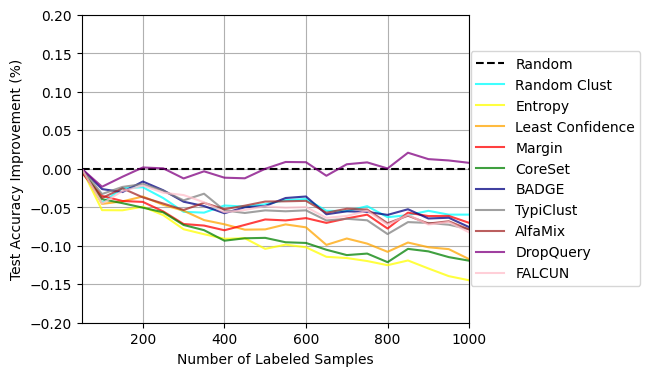

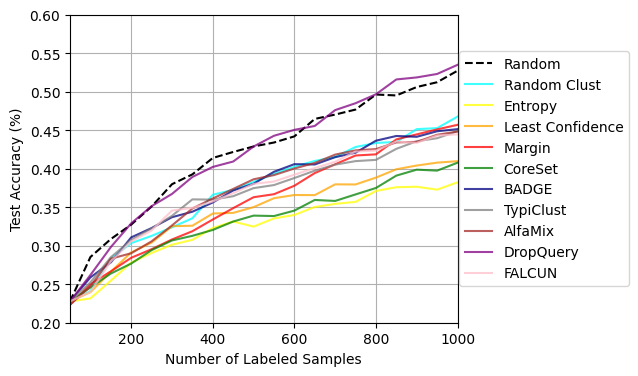

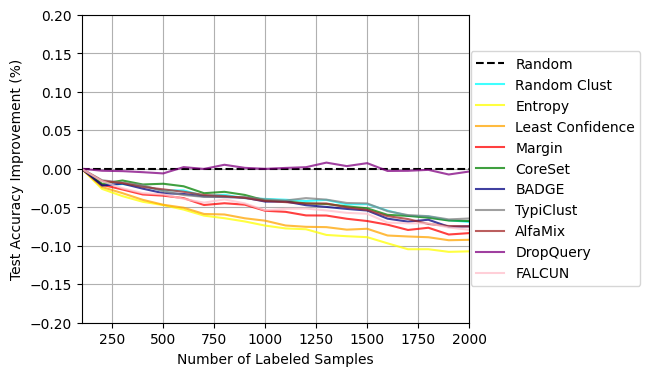

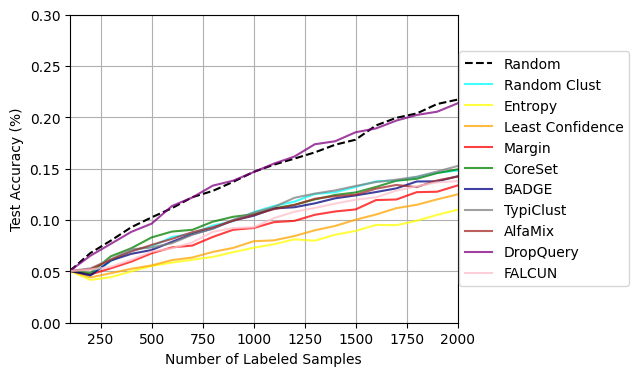

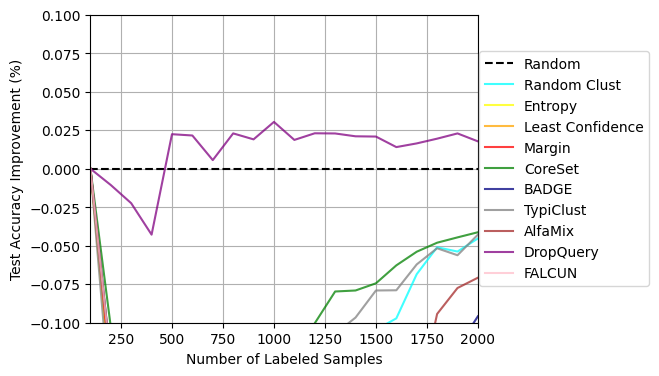

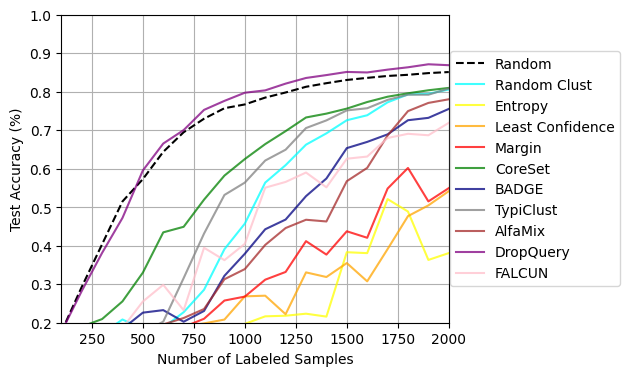

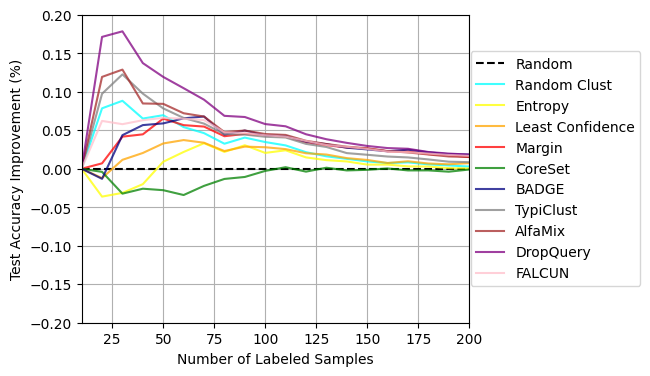

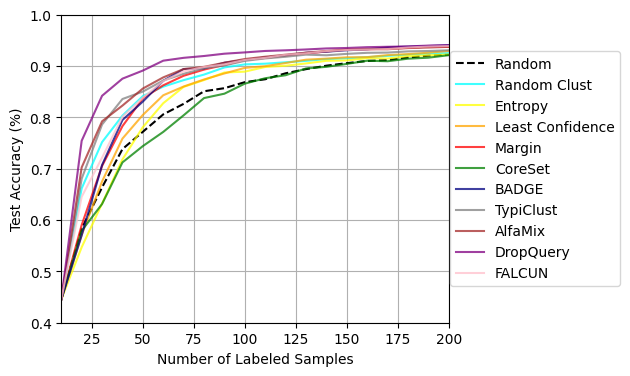

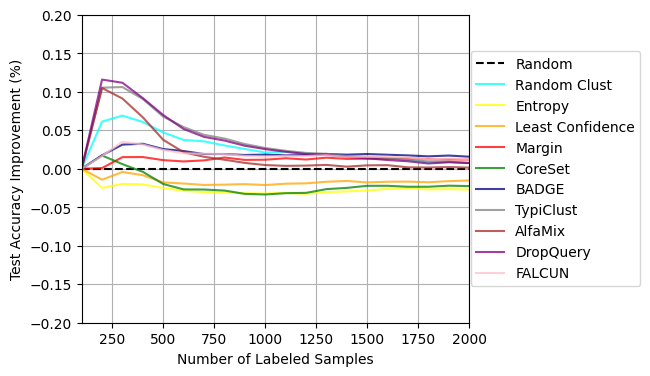

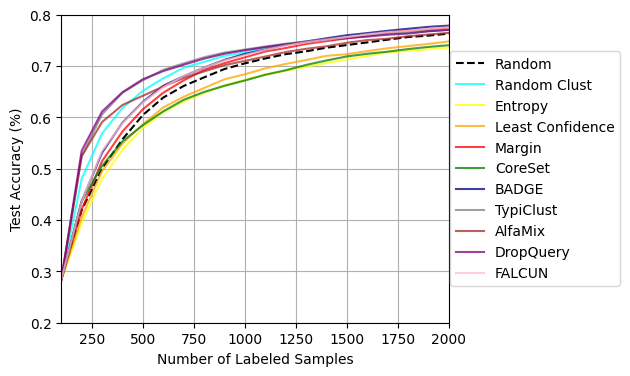

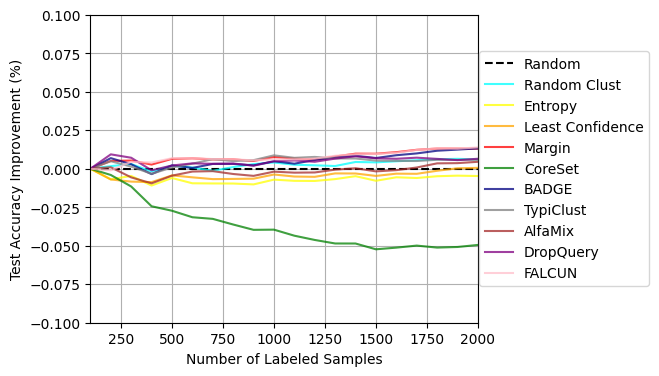

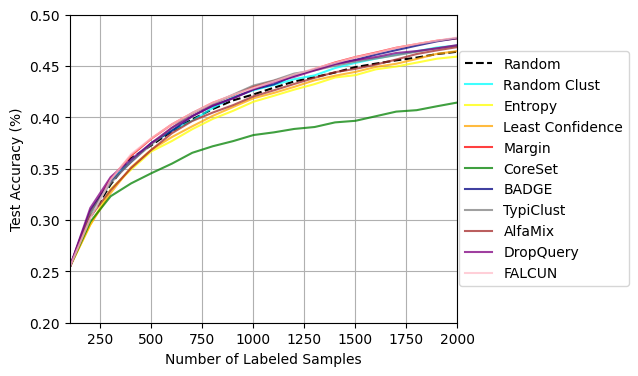

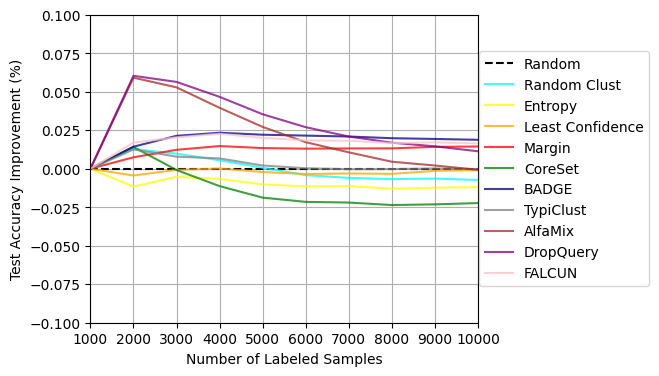

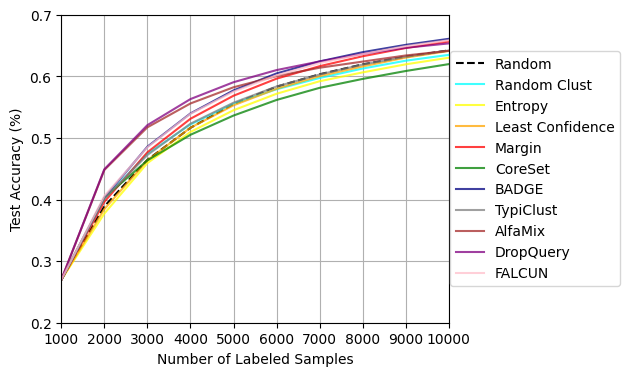

In [18]:
colors = ['royalblue', 'cyan', 'yellow', 'orange', 'red', 'green', 'navy', 'gray', 'brown', 'purple', 'pink']
save = True


for mn in model_names:
    for ds in datasets[mn]:
        query_size = {'CIFAR10' : (50 if mn == 'resnet18' else 10), 'CIFAR100' : 100, 'SVHN' : 100, 'ImageNet' : 1000}[ds]
        n_queries = 10 if ds == 'ImageNet' else 20
        x_ticks = [query_size+i*query_size for i in range(n_queries)]
        plt.figure(figsize=(5, 4))

        for i, qs in enumerate(query_strategies):
            values = np.mean(accs[mn][ds][qs], axis=0)-np.mean(rand_accs[mn][ds], axis=0)
            if qs == 'random':
                plt.plot(x_ticks, values, label=Q[qs], alpha=1, linestyle='--', color='black')
            else:
                plt.plot(x_ticks, values, label=Q[qs], c=colors[i], alpha=0.75)
        lgd = plt.legend(bbox_to_anchor=[1.46, 0.5], loc='center right')
        plt.grid(True)
        plt.xlabel('Number of Labeled Samples')
        plt.ylabel('Test Accuracy Improvement (%)')
        plt.xlim((x_ticks[0], x_ticks[-1]))
        plt.ylim((-0.2, 0.2) if ds in 'CIFAR100' else (-0.1, 0.1))
        if save:
            plt.savefig('./plots/'+mn+'_'+ds+'_rel.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
        else:
            plt.show()

        plt.figure(figsize=(5, 4))

        for i, qs in enumerate(query_strategies):
            values = np.mean(accs[mn][ds][qs], axis=0)
            if qs == 'random':
                plt.plot(x_ticks, values, label=Q[qs], alpha=1, linestyle='--', color='black')
            else:
                plt.plot(x_ticks, values, label=Q[qs], c=colors[i], alpha=0.75)
        lgd = plt.legend(bbox_to_anchor=[1.46, 0.5], loc='center right')
        plt.grid(True)
        plt.xlabel('Number of Labeled Samples')
        plt.ylabel('Test Accuracy (%)')
        plt.xlim((x_ticks[0], x_ticks[-1]))
        plt.ylim({
            'dinov2':{'CIFAR10':(0.4, 1), 'CIFAR100':(0.2, 0.8), 'SVHN':(0.2, 0.5), 'ImageNet' : (0.2, 0.7)},
            'resnet18':{'CIFAR10':(0.2, 0.6), 'CIFAR100':(0.0, 0.3), 'SVHN':(0.2, 1.0), 'ImageNet' : (0.2, 0.7)}}[mn][ds])

        if save:
            plt.savefig('./plots/'+mn+'_'+ds+'_abs.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
        else:
            plt.show()